In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from cv_functions import *

In [2]:
img = cv2.imread(r"Images\Image 1\Blood Cells 1.bmp", cv2.IMREAD_GRAYSCALE)

In [3]:
img = cv2.imread(r"Images\Image 3\Blood Cells 3.bmp", cv2.IMREAD_GRAYSCALE)

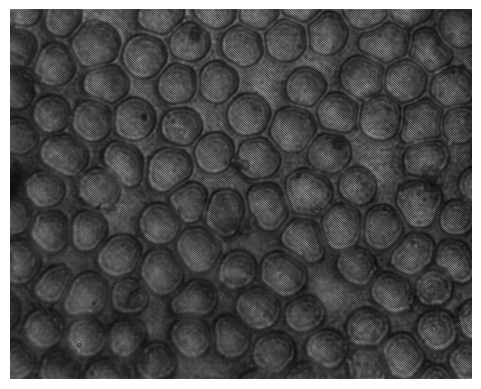

In [4]:
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [5]:
cv2.imwrite("cells.png", img)

True

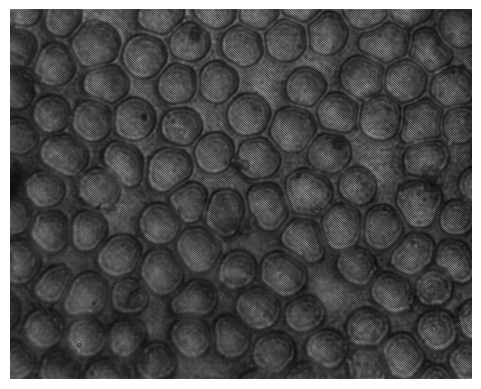

In [6]:
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [13]:
fft = np.fft.fftshift(np.fft.fft2(img))
spectrum = np.log(1 + np.abs(fft))
f_x, f_y = find_plus_one_order_position(spectrum, mask_radius = 15)
filtered_spectrum = filter_spectrum(fft, f_x, f_y, radius=75)
centered_spectrum = center_spectrum(filtered_spectrum, f_x, f_y)
amplitude = np.fft.ifft2(np.fft.ifftshift(centered_spectrum))

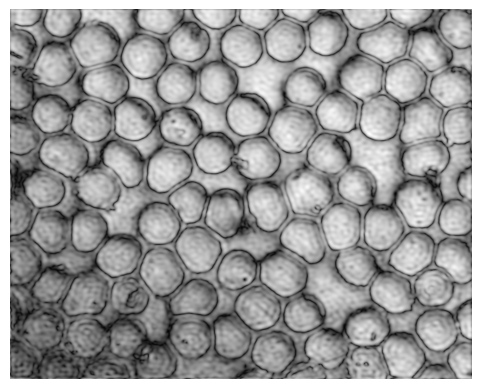

In [14]:

plt.imshow(get_spectrum_image_from_fft(amplitude), cmap='gray')
plt.axis('off')
plt.show()

In [17]:
normalized = cv2.normalize(get_spectrum_image_from_fft(amplitude), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

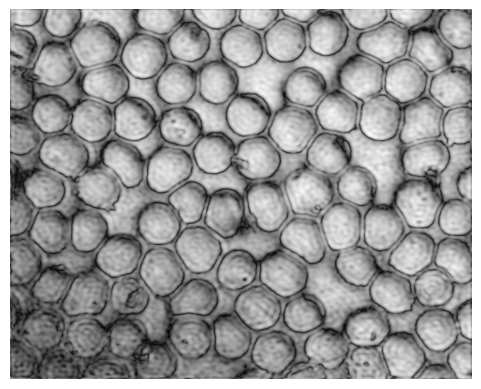

In [19]:
plt.imshow(normalized, cmap='gray')
plt.axis('off')
plt.show()

In [21]:
cv2.imwrite("cells_no_fringes.png", normalized)

True

In [23]:
blurM = cv2.medianBlur(normalized, 5)

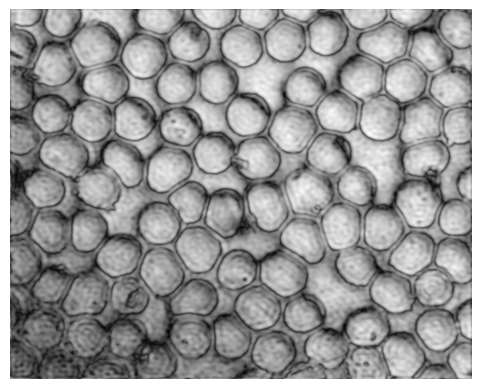

In [25]:
plt.imshow(blurM, cmap='gray')
plt.axis('off')
plt.show()

In [27]:
def pixelVal(pix, r1, s1, r2, s2):
    return np.interp(pix, [0, r1, r2, 255], [0, s1, s2, 255])

r1 = 70
s1 = 0
r2 = 200
s2 = 255

pixelVal_vec = np.vectorize(pixelVal)

In [29]:
contrast_stretched = pixelVal_vec(blurM, r1, s1, r2, s2).astype(np.uint8)

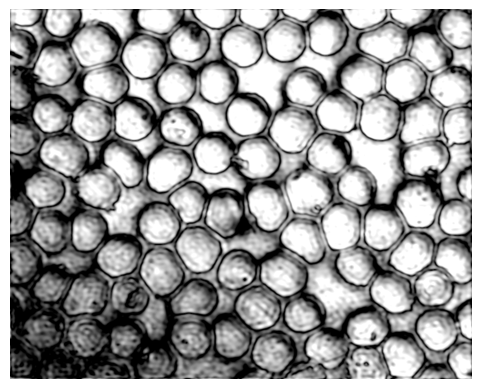

In [30]:
plt.imshow(contrast_stretched, cmap='gray')
plt.axis('off')
plt.show()

In [38]:
edge = cv2.Canny(contrast_stretched, 100, 200)

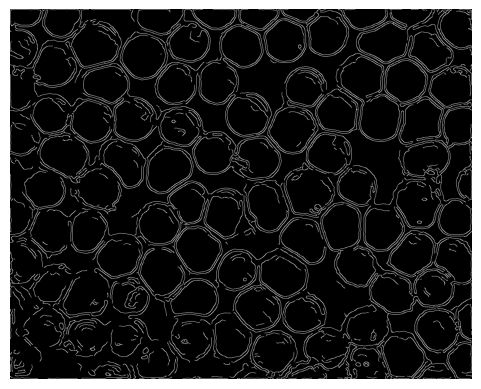

In [40]:
plt.imshow(edge, cmap='gray')
plt.axis('off')
plt.show()

In [44]:
kernel = np.ones((2, 2), np.uint8)
dilation = cv2.dilate(edge, kernel, iterations = 9)
cv2.imwrite("Images/dilation.png", dilation)

True

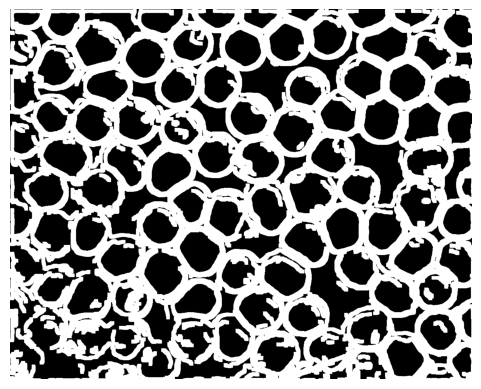

In [46]:
plt.imshow(dilation, cmap='gray')
plt.axis('off')
plt.show()

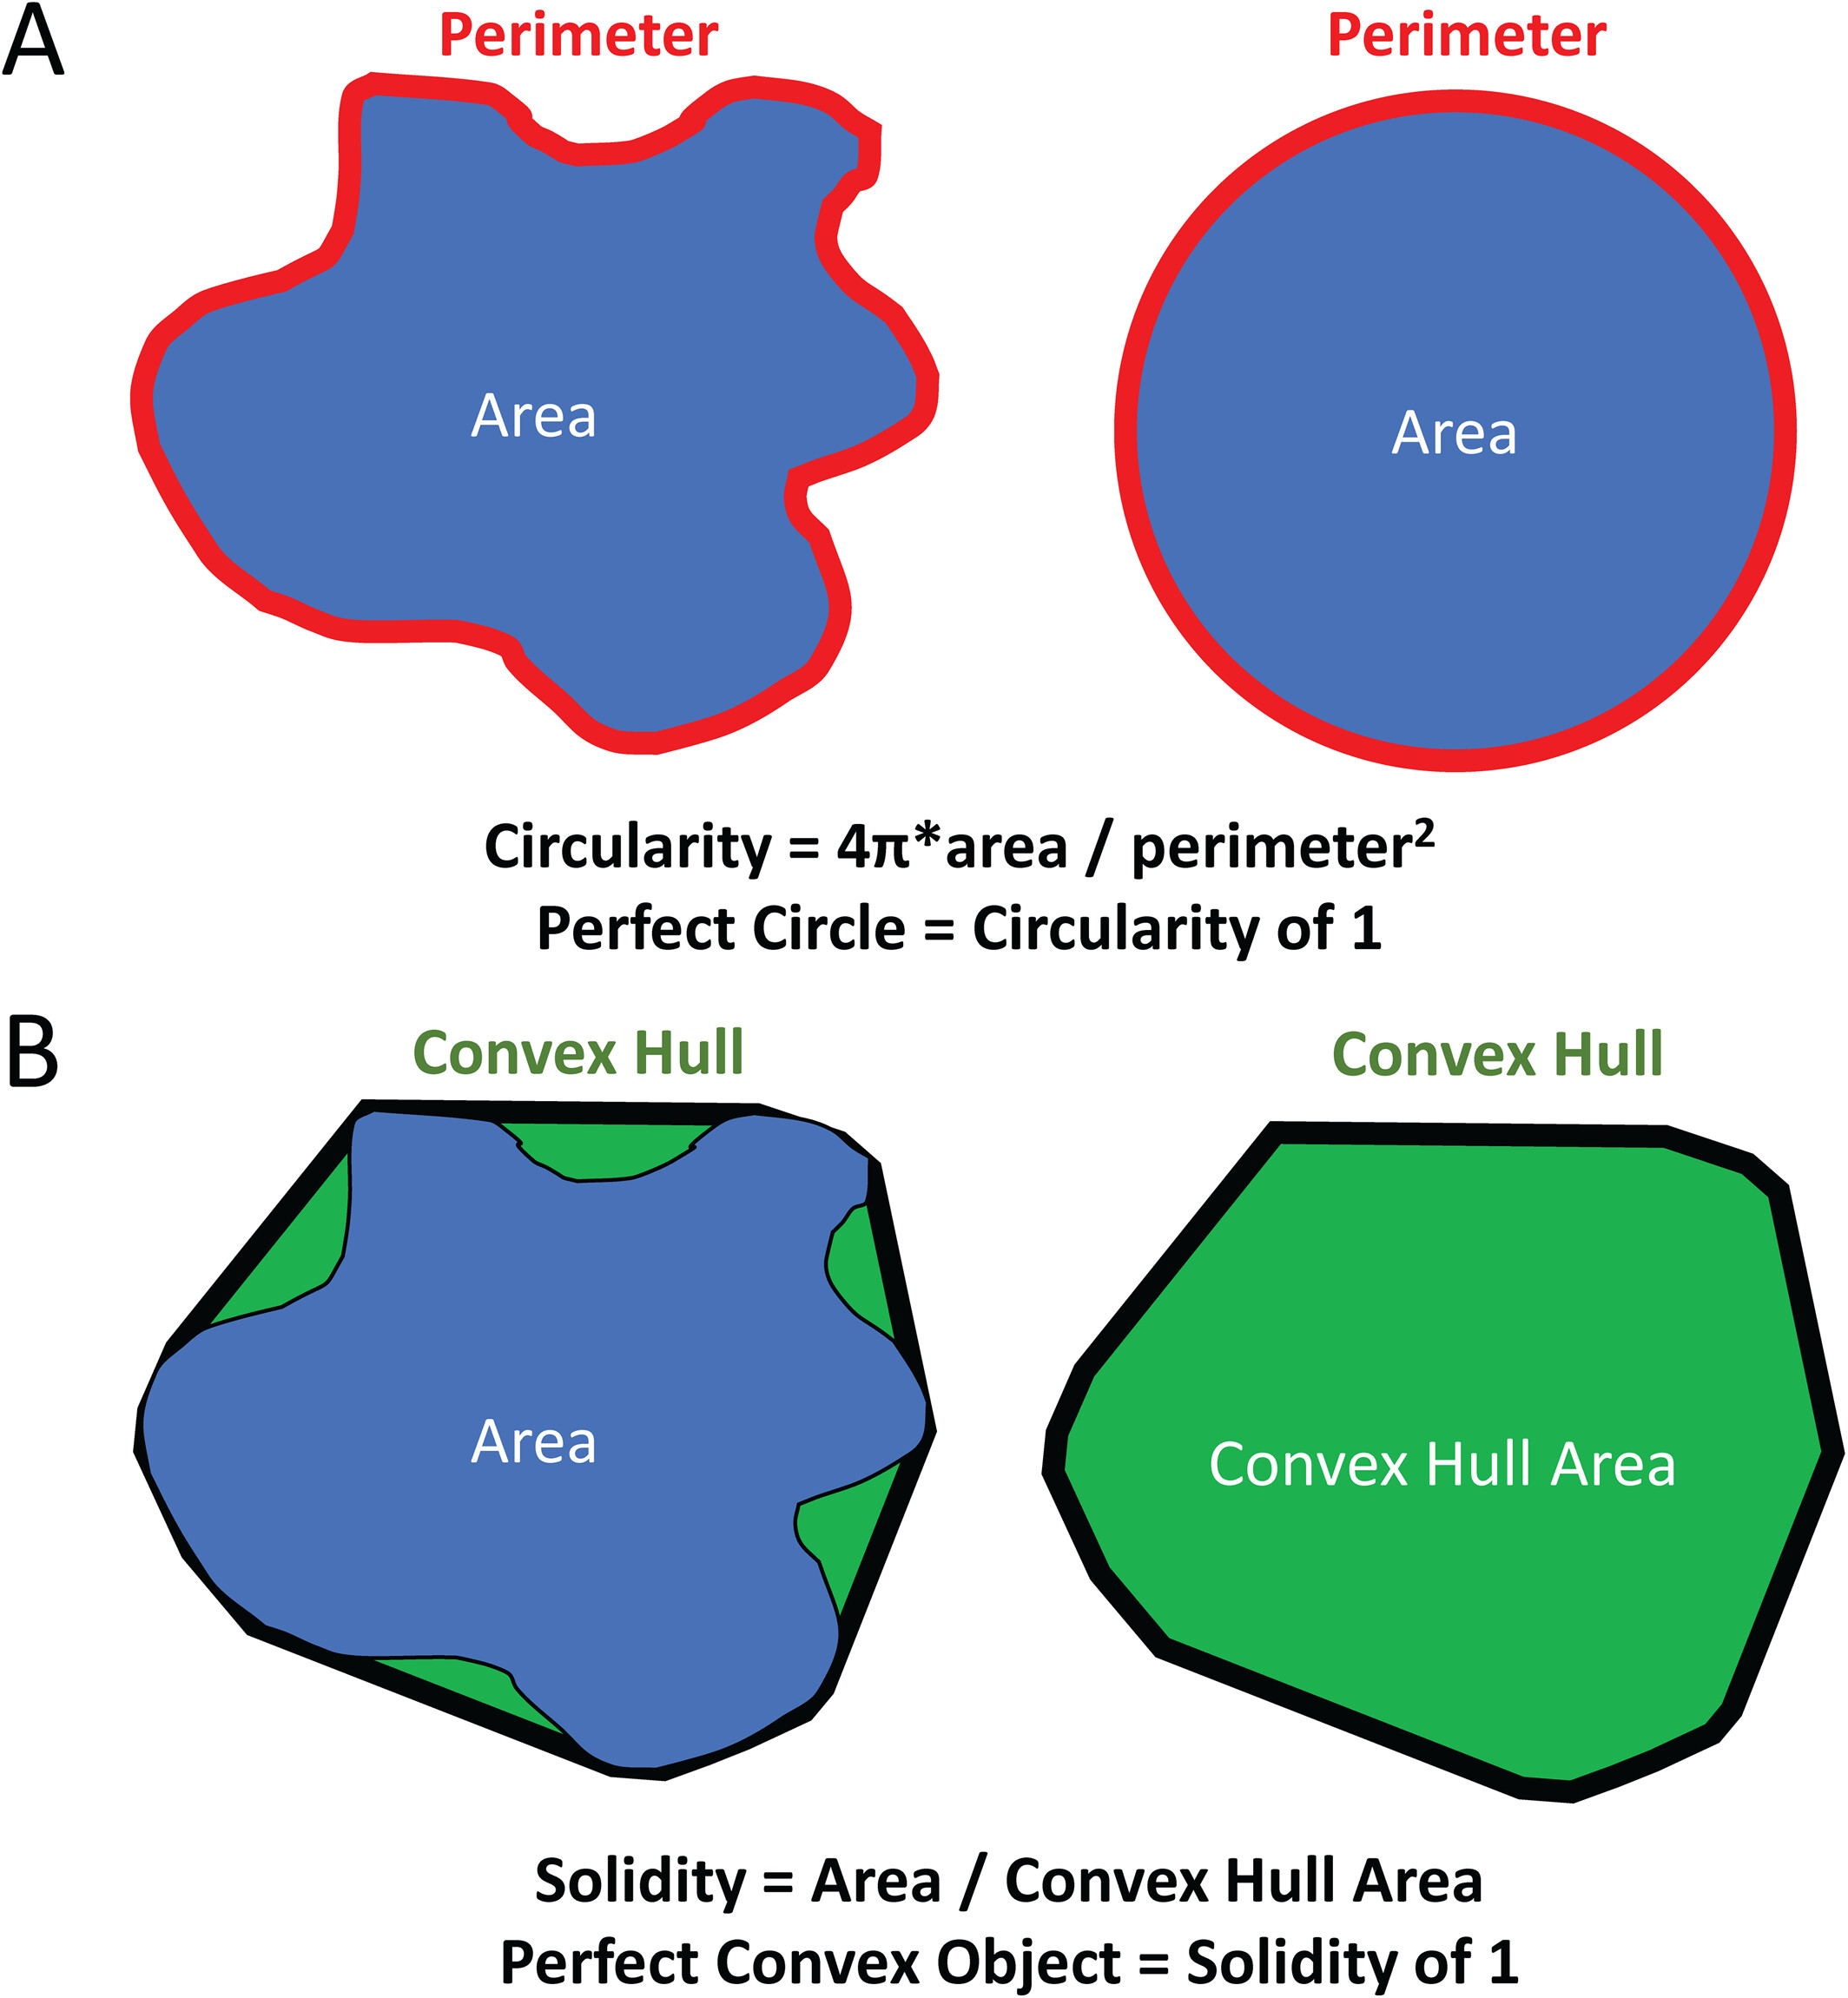

In [48]:
def detect_erythrocytes(contour_image_path, original_image_path, min_area = 500, max_area = 10000, padding=20, 
                             circularity_threshold = 0.5, solidity_threshold = 0.7, eccentricity_threshold = 0.9):

    contour_img = cv2.imread(contour_image_path, cv2.IMREAD_GRAYSCALE)
    original_img = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)

    inverted = cv2.bitwise_not(contour_img)
    _, binary = cv2.threshold(inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    result = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)
    erythrocytes = []
    cell_images = []
    h, w = contour_img.shape
    
    erythrocytes_count = 0
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if area < min_area or area > max_area:
            continue
            
        left = stats[i, cv2.CC_STAT_LEFT]
        top = stats[i, cv2.CC_STAT_TOP]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        
        if (left <= padding or top <= padding or left + width >= w-padding or top + height >= h-padding):
            continue
            
        mask = (labels == i).astype(np.uint8) * 255
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            contour = contours[0]
            
            # Периметр и площадь
            perimeter = cv2.arcLength(contour, True)
            area_contour = cv2.contourArea(contour)
            
            if perimeter > 0:
                circularity = 4 * np.pi * area_contour / (perimeter * perimeter)
            else:
                circularity = 0
            
            epsilon = 0.02 * perimeter
            approx = cv2.approxPolyDP(contour, epsilon, True)
            
            hull = cv2.convexHull(contour)
            hull_area = cv2.contourArea(hull)
            solidity = area_contour / hull_area if hull_area > 0 else 0
            
            if len(contour) >= 5:
                ellipse = cv2.fitEllipse(contour)
                (center, axes, orientation) = ellipse
                major_axis = max(axes)
                minor_axis = min(axes)
                eccentricity = np.sqrt(1 - (minor_axis/major_axis)**2) if major_axis > 0 else 0
            else:
                eccentricity = 1
            
            if circularity > circularity_threshold and solidity > solidity_threshold and eccentricity < eccentricity_threshold:
                erythrocytes_count += 1
            
                center_x = left + width // 2
                center_y = top + height // 2
                
                square_size = max(width, height) + 2 * padding
                
                crop_left = max(0, center_x - square_size // 2)
                crop_top = max(0, center_y - square_size // 2)
                crop_right = min(w, crop_left + square_size)
                crop_bottom = min(h, crop_top + square_size)
                
                if crop_right - crop_left < square_size:
                    crop_left = max(0, crop_right - square_size)
                if crop_bottom - crop_top < square_size:
                    crop_top = max(0, crop_bottom - square_size)
                
                cell_img = original_img[crop_top:crop_bottom, crop_left:crop_right]
                
                if cell_img.shape[0] != cell_img.shape[1]:
                    size = max(cell_img.shape)
                    square_cell = np.zeros((size, size), dtype=np.uint8)
                    y_offset = (size - cell_img.shape[0]) // 2
                    x_offset = (size - cell_img.shape[1]) // 2
                    square_cell[y_offset:y_offset + cell_img.shape[0], 
                               x_offset:x_offset + cell_img.shape[1]] = cell_img
                    cell_img = square_cell
                
                cell_info = {
                    'id': erythrocytes_count,
                    'area': area,
                    'circularity': circularity,
                    'solidity': solidity,
                    'eccentricity': eccentricity,
                    'centroid': (int(centroids[i][0]), int(centroids[i][1])),
                    'bbox': (left, top, width, height),
                    'crop_coords': (crop_left, crop_top, crop_right, crop_bottom)
                }
                
                erythrocytes.append(cell_info)
                cell_images.append(cell_img)
                
                color = (0, 255, 0) 
                
                cv2.rectangle(result, (left, top), (left+width, top+height), color, 2)
                cv2.putText(result, f"E{erythrocytes_count}", (int(centroids[i][0]), int(centroids[i][1])), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    
    print(f"{len(erythrocytes)} erythrocytes detected")
    
    return result, erythrocytes, cell_images

In [50]:
result, erythrocytes, cell_images = detect_erythrocytes(r'Images\contours.png', r"Images\Image 3\Blood Cells 3.bmp", padding = 25)

53 erythrocytes detected


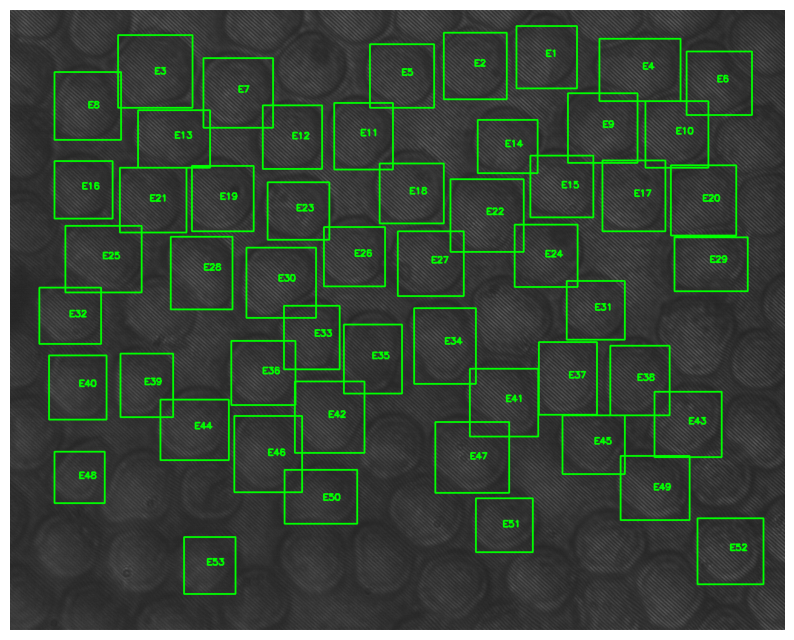

In [52]:
plt.figure(figsize=(10, 10))
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
result, erythrocytes, cell_images = detect_erythrocytes(r'Images\contours.png', r"Images\Image 3\Blood Cells 3.bmp", padding = 25)

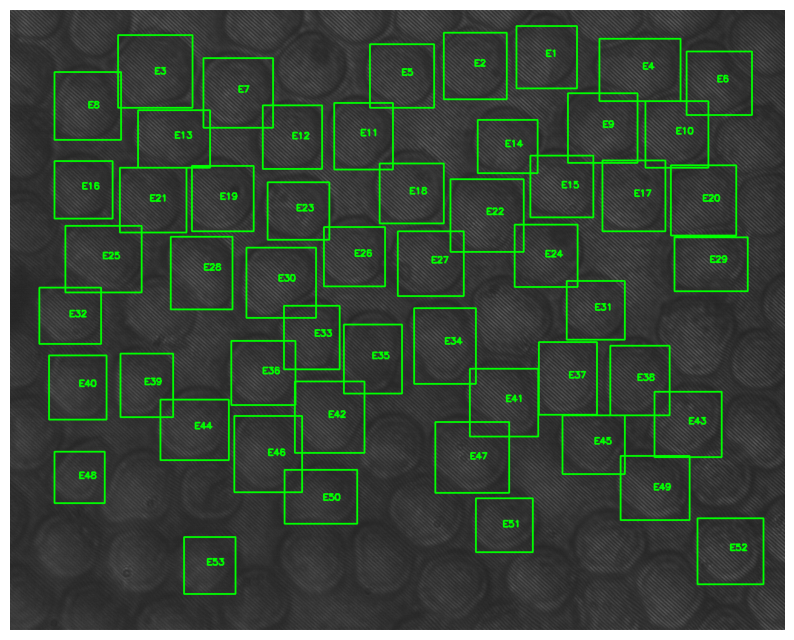

In [54]:
plt.figure(figsize=(10, 10))
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.show()

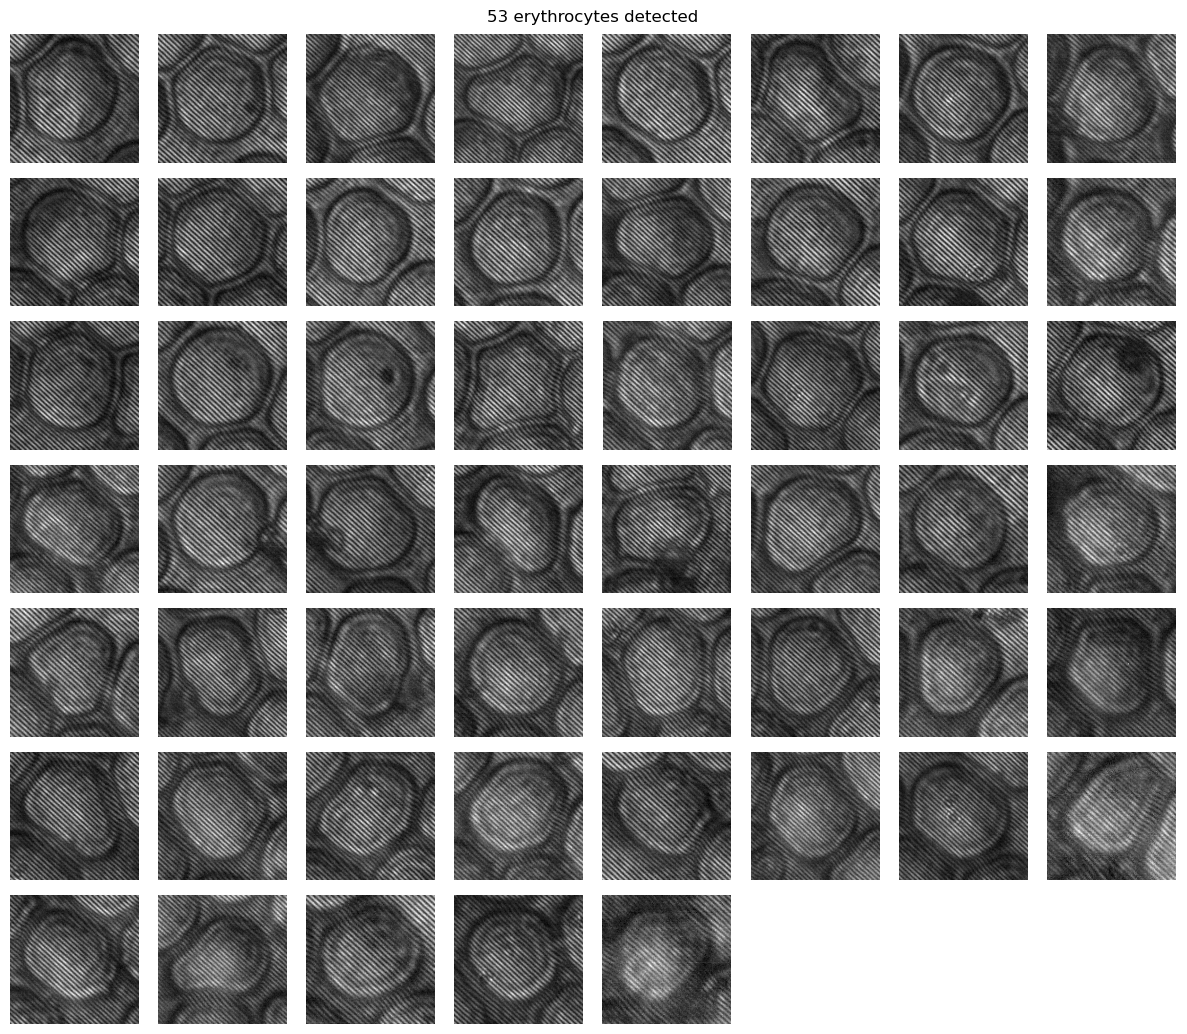

In [56]:
import matplotlib.pyplot as plt
import math

n = len(cell_images)

cols = math.ceil(math.sqrt(n))
cols = max(2, min(cols, 8))

rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
axes = axes.flatten() if rows > 1 or cols > 1 else [axes]

for i in range(n):
    axes[i].imshow(cell_images[i], cmap='gray')
    axes[i].axis('off')

for i in range(n, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'{n} erythrocytes detected')
plt.tight_layout()
plt.show()